In [4]:
import os
import random
import imghdr
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os
import random

C:\Users\REDTECH\AppData\Local\Temp\ipykernel_22624\2500973989.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
# -------------------------------
# 1. Data Loading & Image Selection
# -------------------------------
data_root = 'fruits'
image_exts = ['jpeg', 'jpg', 'bmp', 'png']
max_images_per_class = 1000  # Limit for each class

In [6]:
# Dictionary to store selected image paths for each class
selected_images = {}

In [7]:
# Loop through each main folder (e.g., Apple, Banana, etc.) inside "Fruits"
for fruit in os.listdir(data_root):
    fruit_dir = os.path.join(data_root, fruit)
    if not os.path.isdir(fruit_dir):
        continue  # Skip if not a directory

    # Get valid class names (those starting with "Fresh_" or "Spoiled_") inside the fruit folder
    valid_classes = [d for d in os.listdir(fruit_dir) if d.endswith("_fresh") or d.endswith("_spoiled")]
    print(f"\nProcessing fruit: {fruit}")
    print(f"Valid classes: {valid_classes}")

    for class_name in valid_classes:
        class_dir = os.path.join(fruit_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        valid_images = []
        for file in os.listdir(class_dir):
            image_path = os.path.join(class_dir, file)
            try:
                tip = imghdr.what(image_path)
                if tip in image_exts:
                    valid_images.append(image_path)
            except Exception as e:
                print(f"Issue reading image: {image_path} - {e}")

        print(f"{class_name}: found {len(valid_images)} valid images")
        # Randomly select up to max_images_per_class images (without deleting any files)
        selected = random.sample(valid_images, min(len(valid_images), max_images_per_class))
        selected_images[class_name] = selected
        print(f"{class_name}: selected {len(selected)} images for dataset")


Processing fruit: apple
Valid classes: ['apple_fresh', 'apple_moderately_fresh', 'apple_spoiled']
apple_fresh: found 300 valid images
apple_fresh: selected 300 images for dataset
apple_moderately_fresh: found 300 valid images
apple_moderately_fresh: selected 300 images for dataset
apple_spoiled: found 300 valid images
apple_spoiled: selected 300 images for dataset

Processing fruit: banana
Valid classes: ['banana_fresh', 'banana_moderately_fresh', 'banana_spoiled']
banana_fresh: found 500 valid images
banana_fresh: selected 500 images for dataset
banana_moderately_fresh: found 500 valid images
banana_moderately_fresh: selected 500 images for dataset
banana_spoiled: found 500 valid images
banana_spoiled: selected 500 images for dataset

Processing fruit: carrot
Valid classes: ['carrot_fresh', 'carrot_moderately_fresh', 'carrot_spoiled']
carrot_fresh: found 302 valid images
carrot_fresh: selected 302 images for dataset
carrot_moderately_fresh: found 300 valid images
carrot_moderately_fr

In [8]:
# -------------------------------
# 2. Combine Images & Create Labels
# -------------------------------
all_image_paths = []
all_labels = []

# Define the desired order of classes
desired_order = [
    'apple_fresh', 'apple_spoiled',
    'banana_fresh', 'banana_spoiled',
    'carrot_fresh', 'carrot_spoiled',
    'orange_fresh', 'orange_spoiled',
    'tomato_fresh', 'tomato_spoiled'
]

In [9]:
# Order the available classes accordingly (only classes found will be used)
ordered_class_names = [cls for cls in desired_order if cls in selected_images]

In [10]:
# Combine filepaths and assign labels (the label index is based on ordered_class_names)
for idx, class_name in enumerate(ordered_class_names):
    image_list = selected_images.get(class_name, [])
    all_image_paths.extend(image_list)
    all_labels.extend([idx] * len(image_list))

In [11]:
# Create a mapping from label index to class names
label_mapping = {idx: name for idx, name in enumerate(ordered_class_names)}

In [12]:
print("\nTotal images selected across all classes:", len(all_image_paths))
print("Class Names:", ordered_class_names)
print("Number of Classes:", len(ordered_class_names))


Total images selected across all classes: 3400
Class Names: ['apple_fresh', 'apple_spoiled', 'banana_fresh', 'banana_spoiled', 'carrot_fresh', 'carrot_spoiled', 'orange_fresh', 'orange_spoiled', 'tomato_fresh', 'tomato_spoiled']
Number of Classes: 10


In [13]:
# -------------------------------
# 3. Manual Train/Validation Split (80/20)
# -------------------------------
# Combine paths and labels into a list of tuples and shuffle
combined = list(zip(all_image_paths, all_labels))
random.shuffle(combined)
all_image_paths, all_labels = zip(*combined)
all_image_paths = list(all_image_paths)
all_labels = list(all_labels)

In [14]:
# 80% for training, 20% for validation
split_index = int(len(all_image_paths) * 0.8)
train_paths = all_image_paths[:split_index]
train_labels = all_labels[:split_index]
val_paths = all_image_paths[split_index:]
val_labels = all_labels[split_index:]

In [15]:
# Convert lists to TensorFlow tensors
train_paths_tensor = tf.constant(train_paths, dtype=tf.string)
train_labels_tensor = tf.constant(train_labels, dtype=tf.int32)
val_paths_tensor = tf.constant(val_paths, dtype=tf.string)
val_labels_tensor = tf.constant(val_labels, dtype=tf.int32)

In [16]:
# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths_tensor, train_labels_tensor))
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths_tensor, val_labels_tensor))

In [17]:
# -------------------------------
# 4. Data Preprocessing
# -------------------------------
def process_image(path, label):
    # Read and decode the image file (assuming JPEG images)
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    # Preprocess the image for MobileNetV2 (scales pixels to [-1, 1])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

In [18]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(process_image, num_parallel_calls=AUTOTUNE)
val_dataset = val_dataset.map(process_image, num_parallel_calls=AUTOTUNE)

In [19]:
batch_size = 32
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(batch_size).prefetch(AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(AUTOTUNE)

In [20]:
# -------------------------------
# 5. Build & Train the Model
# -------------------------------
# Load MobileNetV2 as base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

In [21]:
base_model.trainable = False

In [22]:
inputs = base_model.input
x = tf.keras.layers.Dense(128, activation='relu')(base_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
# Output layer: number of units equals number of classes
outputs = tf.keras.layers.Dense(len(ordered_class_names), activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5


85/85 ━━━━━━━━━━━━━━━━━━━━ 46s 491ms/step - accuracy: 0.7021 - loss: 0.9394 - val_accuracy: 0.9515 - val_loss: 0.1540
Epoch 2/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 43s 490ms/step - accuracy: 0.9758 - loss: 0.0845 - val_accuracy: 0.9618 - val_loss: 0.1246
Epoch 3/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 44s 514ms/step - accuracy: 0.9904 - loss: 0.0367 - val_accuracy: 0.9662 - val_loss: 0.0894
Epoch 4/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 46s 528ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 0.9765 - val_loss: 0.0806
Epoch 5/5
85/85 ━━━━━━━━━━━━━━━━━━━━ 46s 530ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9794 - val_loss: 0.0817


22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 440ms/step - accuracy: 0.9844 - loss: 0.0627

Model Accuracy on Validation Set: 0.9765


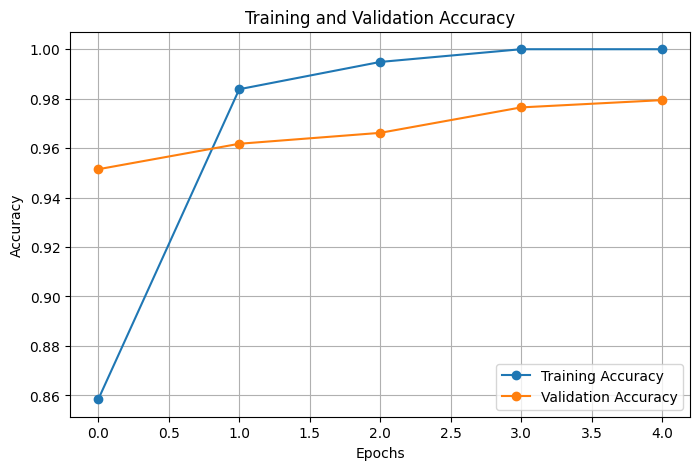

In [25]:
# -------------------------------
# 6. Evaluate Model & Plot Accuracy Curves
# -------------------------------

# Print final accuracy
test_loss, test_acc = model.evaluate(val_dataset)
print(f"\nModel Accuracy on Validation Set: {test_acc:.4f}")

# Plot training & validation accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

In [26]:
# -------------------------------
# 6. Save the Model & Define Prediction Function
# -------------------------------
model.save(os.path.join('models','Fruit_Classifier.h5'))

In [27]:
def predict_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)
    pred_idx = np.argmax(pred, axis=-1)[0]
    return label_mapping[pred_idx]

In [28]:
predicted_label = predict_image(r"fruits\orange\orange_spoiled\orange_spoiled_2.jpg")
print("Predicted label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step
Predicted label: orange_spoiled


In [29]:
import os
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load the saved model from 'models/Fruit_Classifier.h5'
model_path = os.path.join('models', 'Fruit_Classifier.h5')
model = tf.keras.models.load_model(model_path)

# Define the label mapping (ensure this matches the one used during training)
label_mapping = {
    0: 'apple_fresh',
    1: 'apple_spoiled',
    2: 'banana_fresh',
    3: 'banana_spoiled',
    4: 'carrot_fresh',
    5: 'carrot_spoiled',
    6: 'orange_fresh',
    7: 'orange_spoiled',
    8: 'tomato_fresh',
    9: 'tomato_spoiled'
}

def predict_image(image_path):
    # Load the image with target size 224x224
    img = load_img(image_path, target_size=(224, 224))
    img = img_to_array(img)
    # Preprocess the image for MobileNetV2 (scales pixels to [-1, 1])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    # Add a batch dimension
    img = np.expand_dims(img, axis=0)
    # Predict and get the class index
    pred = model.predict(img)
    pred_idx = np.argmax(pred, axis=-1)[0]
    return label_mapping[pred_idx]

# Define the new image path
new_image_path = r"fruits\tomato\tomato_spoiled\d (143).png"

# Get and print the predicted label
predicted_label = predict_image(new_image_path)
print("Predicted label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
Predicted label: tomato_spoiled
